# 02 — Train CAMUS with nnU-Net v2

## Goal

This notebook follows one complete, linear nnU-Net v2 training run:

```text
CAMUS NIfTI files
  → nnU-Net dataset layout
  → automatic planning and preprocessing
  → one 2D model on fold 0
  → prediction on the held-out test patients
  → inspect one prediction
```

The first run deliberately excludes five-fold training, ensembling, extensive tuning, and extra evaluation artifacts. The goal is to understand the complete training path once.

The original CAMUS NIfTI files will not be copied. Later, the nnU-Net dataset layout will use symbolic links to the existing files under `data/raw/camus`.


## Step 1 — Install nnU-Net v2 in the project environment

The project already has a Python 3.12 environment and a CUDA-enabled PyTorch installation. `uv add nnunetv2` will:

1. add `nnunetv2` to `pyproject.toml`;
2. resolve its Python dependencies in `uv.lock`;
3. install those dependencies into the existing `.venv`.

It does not install an NVIDIA driver or a system CUDA Toolkit. nnU-Net trains through the CUDA-enabled PyTorch package that is already in this project.

First derive the project root from the notebook location.


In [4]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

print("Notebook directory:", NOTEBOOK_DIR)
print("Project root:     ", PROJECT_ROOT)


Notebook directory: /home/felix/Workspace/projects/dl-segmentation-camus/notebooks
Project root:      /home/felix/Workspace/projects/dl-segmentation-camus


Run the following command as a shell command from the notebook. The leading `!` means that IPython sends the line to the shell; it is not Python syntax.


In [5]:
!uv --directory {PROJECT_ROOT} add nnunetv2


Resolved 131 packages in 1ms
Checked 100 packages in 1ms


Finally, read the installed package version and confirm that the existing PyTorch installation still sees the GPU. This is the only environment check needed before preparing the dataset.


In [6]:
from importlib.metadata import version
import torch

print("nnU-Net v2:", version("nnunetv2"))
print("PyTorch:     ", torch.__version__)
print("CUDA ready:  ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:         ", torch.cuda.get_device_name(0))


nnU-Net v2: 2.8.1
PyTorch:      2.12.1+cu132
CUDA ready:   True
GPU:          NVIDIA GeForce RTX 4090


### Step 1 conclusion

After these cells succeed, nnU-Net v2 is part of the same reproducible project environment and can use the existing CUDA-enabled PyTorch installation.


## Step 2 — Define one project-local nnU-Net workspace

nnU-Net requires three root directories:

- `nnUNet_raw`: dataset descriptions and links to the original images;
- `nnUNet_preprocessed`: arrays produced by nnU-Net for efficient training;
- `nnUNet_results`: checkpoints and training logs.

All three remain under this project. The raw layout will contain symbolic links, so the original CAMUS NIfTI files are not copied. Environment variables tell nnU-Net commands where these directories are located.


In [7]:
import os

DATASET_ID = 501
DATASET_NAME = "Dataset501_CAMUS"

CAMUS_ROOT = PROJECT_ROOT / "data" / "raw" / "camus"
NNUNET_ROOT = PROJECT_ROOT / "data" / "nnunet"
NNUNET_RAW = NNUNET_ROOT / "nnUNet_raw"
NNUNET_PREPROCESSED = NNUNET_ROOT / "nnUNet_preprocessed"
NNUNET_RESULTS = NNUNET_ROOT / "nnUNet_results"

DATASET_ROOT = NNUNET_RAW / DATASET_NAME
IMAGES_TR = DATASET_ROOT / "imagesTr"
LABELS_TR = DATASET_ROOT / "labelsTr"
IMAGES_TS = DATASET_ROOT / "imagesTs"
TEST_LABELS = NNUNET_ROOT / "test_labels"
PREDICTIONS = NNUNET_ROOT / "predictions"

for directory in (
    NNUNET_RAW, NNUNET_PREPROCESSED, NNUNET_RESULTS,
    IMAGES_TR, LABELS_TR, IMAGES_TS, TEST_LABELS,
):
    directory.mkdir(parents=True, exist_ok=True)

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREPROCESSED)
os.environ["nnUNet_results"] = str(NNUNET_RESULTS)

print("Raw:         ", NNUNET_RAW)
print("Preprocessed:", NNUNET_PREPROCESSED)
print("Results:     ", NNUNET_RESULTS)


Raw:          /home/felix/Workspace/projects/dl-segmentation-camus/data/nnunet/nnUNet_raw
Preprocessed: /home/felix/Workspace/projects/dl-segmentation-camus/data/nnunet/nnUNet_preprocessed
Results:      /home/felix/Workspace/projects/dl-segmentation-camus/data/nnunet/nnUNet_results


### Step 2 conclusion

nnU-Net now has one project-local workspace. `data/nnunet/` is generated locally and ignored by Git.


## Step 3 — Reuse the existing patient split

The split remains patient-level. Each patient contributes four independent 2D cases: two cardiac views (`2CH`, `4CH`) at two phases (`ED`, `ES`).

The 400 training patients and 50 validation patients form nnU-Net's labelled development pool. The 50 test patients remain completely outside training.


In [8]:
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"

def read_patient_split(filename):
    return (SPLIT_DIR / filename).read_text().splitlines()

TRAIN_PATIENTS = read_patient_split("subgroup_training.txt")
VAL_PATIENTS = read_patient_split("subgroup_validation.txt")
TEST_PATIENTS = read_patient_split("subgroup_testing.txt")

assert (len(TRAIN_PATIENTS), len(VAL_PATIENTS), len(TEST_PATIENTS)) == (400, 50, 50)
assert set(TRAIN_PATIENTS).isdisjoint(VAL_PATIENTS)
assert set(TRAIN_PATIENTS).isdisjoint(TEST_PATIENTS)
assert set(VAL_PATIENTS).isdisjoint(TEST_PATIENTS)

VIEWS = ("2CH", "4CH")
PHASES = ("ED", "ES")

def build_case_ids(patient_ids):
    return [
        f"{patient_id}_{view}_{phase}"
        for patient_id in patient_ids
        for view in VIEWS
        for phase in PHASES
    ]

TRAIN_CASE_IDS = build_case_ids(TRAIN_PATIENTS)
VAL_CASE_IDS = build_case_ids(VAL_PATIENTS)
TEST_CASE_IDS = build_case_ids(TEST_PATIENTS)

print("Training cases:  ", len(TRAIN_CASE_IDS))
print("Validation cases:", len(VAL_CASE_IDS))
print("Test cases:      ", len(TEST_CASE_IDS))
print("Example case:    ", TRAIN_CASE_IDS[0])


Training cases:   1600
Validation cases: 200
Test cases:       200
Example case:     patient0001_2CH_ED


### Step 3 conclusion

The experiment still uses 1,600 training cases, 200 validation cases, and 200 held-out test cases. All four cases from one patient stay in the same split.


## Step 4 — Create the nnU-Net filenames without copying data

nnU-Net connects files through a case identifier. For one grayscale case:

```text
imagesTr/patient0001_2CH_ED_0000.nii.gz  # input channel 0
labelsTr/patient0001_2CH_ED.nii.gz       # integer target mask
```

The new paths are symbolic links to the existing CAMUS files. A link stores a path, not another copy of the image.


In [9]:
def link_case(patient_id, view, phase, image_folder, label_folder=None):
    case_id = f"{patient_id}_{view}_{phase}"
    patient_dir = CAMUS_ROOT / patient_id
    source_image = patient_dir / f"{case_id}.nii.gz"
    linked_image = image_folder / f"{case_id}_0000.nii.gz"

    if not linked_image.exists():
        linked_image.symlink_to(source_image)

    if label_folder is not None:
        source_label = patient_dir / f"{case_id}_gt.nii.gz"
        linked_label = label_folder / f"{case_id}.nii.gz"
        if not linked_label.exists():
            linked_label.symlink_to(source_label)

for patient_id in TRAIN_PATIENTS + VAL_PATIENTS:
    for view in VIEWS:
        for phase in PHASES:
            link_case(patient_id, view, phase, IMAGES_TR, LABELS_TR)

for patient_id in TEST_PATIENTS:
    for view in VIEWS:
        for phase in PHASES:
            link_case(patient_id, view, phase, IMAGES_TS, TEST_LABELS)

print("imagesTr:", len(list(IMAGES_TR.glob("*.nii.gz"))))
print("labelsTr:", len(list(LABELS_TR.glob("*.nii.gz"))))
print("imagesTs:", len(list(IMAGES_TS.glob("*.nii.gz"))))
print("Example link:", next(IMAGES_TR.iterdir()))
print("Points to:   ", next(IMAGES_TR.iterdir()).resolve())


imagesTr: 1800
labelsTr: 1800
imagesTs: 200
Example link: /home/felix/Workspace/projects/dl-segmentation-camus/data/nnunet/nnUNet_raw/Dataset501_CAMUS/imagesTr/patient0139_4CH_ED_0000.nii.gz
Points to:    /home/felix/Workspace/projects/dl-segmentation-camus/data/raw/camus/patient0139/patient0139_4CH_ED.nii.gz


### Step 4 conclusion

The nnU-Net raw layout now exposes 1,800 labelled development cases and 200 test images while continuing to store only one physical copy of each CAMUS NIfTI file.


## Step 5 — Describe the task and define fold 0

`dataset.json` tells nnU-Net that each image has one ultrasound channel and each mask uses four class IDs. `splits_final.json` tells it exactly which case identifiers belong to training and validation.

The split file contains only fold 0 because this first run trains one model rather than five cross-validation models.


In [10]:
import json

dataset_description = {
    "channel_names": {"0": "ultrasound"},
    "labels": {
        "background": 0,
        "LV cavity": 1,
        "myocardium": 2,
        "left atrium": 3,
    },
    "numTraining": len(TRAIN_CASE_IDS) + len(VAL_CASE_IDS),
    "file_ending": ".nii.gz",
}

fold_zero = [{"train": TRAIN_CASE_IDS, "val": VAL_CASE_IDS}]

(DATASET_ROOT / "dataset.json").write_text(
    json.dumps(dataset_description, indent=2) + "\n"
)
(DATASET_ROOT / "splits_final.json").write_text(
    json.dumps(fold_zero, indent=2) + "\n"
)

print(json.dumps(dataset_description, indent=2))
print("Fold 0 training cases:  ", len(fold_zero[0]["train"]))
print("Fold 0 validation cases:", len(fold_zero[0]["val"]))


{
  "channel_names": {
    "0": "ultrasound"
  },
  "labels": {
    "background": 0,
    "LV cavity": 1,
    "myocardium": 2,
    "left atrium": 3
  },
  "numTraining": 1800,
  "file_ending": ".nii.gz"
}
Fold 0 training cases:   1600
Fold 0 validation cases: 200


### Step 5 conclusion

The raw dataset is complete. We chose the case definitions, labels, patient split, and the fact that this is a single-fold experiment; nnU-Net has not yet chosen a network or changed the images.


## Step 6 — Let nnU-Net plan and preprocess the 2D experiment

This command performs three operations:

1. **Fingerprinting:** measure image shapes, pixel spacing, intensities, and label properties.
2. **Planning:** choose target spacing, patch size, batch size, and U-Net topology.
3. **Preprocessing:** resample and normalize the cases into an efficient training representation.

`-c 2d` requests only the two-dimensional configuration. The integrity check is run once to confirm that every image has a matching valid mask.


In [11]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity -c 2d


Fingerprint extraction...
Dataset501_CAMUS
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Extracting dataset fingerprint: 100%|█████| 1800/1800 [00:03<00:00, 458.42it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 10, 'patch_size': (np.int64(512), np.int64(640)), 'median_image_size_in_voxels': array([486., 589.]), 'spacing': array([0.308, 0.3

## Step 7 — Read the decisions made by nnU-Net

The generated plan is the main difference from the hand-written baseline. Instead of assuming `512 × 416`, batch size 8, and fixed channel widths, we now read the configuration nnU-Net derived from the CAMUS dataset.


In [12]:
PREPROCESSED_DATASET = NNUNET_PREPROCESSED / DATASET_NAME
plans = json.loads((PREPROCESSED_DATASET / "nnUNetPlans.json").read_text())
configuration = plans["configurations"]["2d"]
architecture = configuration["architecture"]
architecture_settings = architecture["arch_kwargs"]
copied_split = json.loads((PREPROCESSED_DATASET / "splits_final.json").read_text())

print("Image reader:       ", plans["image_reader_writer"])
print("Target spacing:     ", configuration["spacing"])
print("Median image size:  ", configuration["median_image_size_in_voxels"])
print("Training patch size:", configuration["patch_size"])
print("Batch size:         ", configuration["batch_size"])
print("Normalization:      ", configuration["normalization_schemes"])
print("Network class:      ", architecture["network_class_name"])
print("Number of stages:   ", architecture_settings["n_stages"])
print("Features per stage: ", architecture_settings["features_per_stage"])
print("Fold 0 cases:       ", len(copied_split[0]["train"]), "train +", len(copied_split[0]["val"]), "val")


Image reader:        SimpleITKIO
Target spacing:      [0.30799999833106995, 0.30799999833106995]
Median image size:   [486.0, 589.0]
Training patch size: [512, 640]
Batch size:          10
Normalization:       ['ZScoreNormalization']
Network class:       dynamic_network_architectures.architectures.unet.PlainConvUNet
Number of stages:    8
Features per stage:  [32, 64, 128, 256, 512, 512, 512, 512]
Fold 0 cases:        1600 train + 200 val


### Step 7 conclusion

The plan records exactly what nnU-Net automated. These values should be interpreted before starting training because they determine the tensor sizes and the generated U-Net architecture.


## Step 8 — Train one 2D model on fold 0

nnU-Net still performs the same learning cycle as the hand-written model:

```text
sample and augment a training patch
  → U-Net forward pass
  → Dice + CrossEntropy loss
  → backward pass
  → SGD parameter update
```

The standard `nnUNetTrainer` uses SGD with momentum and a polynomial learning-rate schedule. By default it runs 1,000 epochs with 250 sampled training iterations per epoch. This is a real nnU-Net baseline and can take several hours. If training is interrupted, rerun the command with `--c` to continue from its latest checkpoint.

We do not add `--npz` because this experiment does not build an ensemble, so large validation probability files are unnecessary.


In [2]:
!nnUNetv2_train {DATASET_ID} 2d 0 -device cuda --c



############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Traceback (most recent call last):
  File "/home/felix/Workspace/projects/dl-segmentation-camus/.venv/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 46, in get_trainer_from_args
    dataset_name_or_id = int(dataset_name_or_id)
                         ^^^^^^^^^^^^^^^^^^^^^^^
ValueError: invalid literal for int() with base 10: '{DATASET_ID}'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/felix/Workspace/projects/dl-segmentation-camus/.venv/bin/nnUNetv2_train", line 10, in <module>
    sys.exit(run_training_entry())
             ^^^^^^^^^^^^^^^^^^^^
  File "/home/felix/Workspace/projects/dl-segmentation-camus/.venv/lib/pytho

In [3]:
from pathlib import Path
import os

PROJECT_ROOT = Path(
    "/home/felix/Workspace/projects/dl-segmentation-camus"
)

NNUNET_ROOT = PROJECT_ROOT / "data" / "nnunet"

os.environ["nnUNet_raw"] = str(
    NNUNET_ROOT / "nnUNet_raw"
)
os.environ["nnUNet_preprocessed"] = str(
    NNUNET_ROOT / "nnUNet_preprocessed"
)
os.environ["nnUNet_results"] = str(
    NNUNET_ROOT / "nnUNet_results"
)

!nnUNetv2_train 501 2d 0 -device cuda --c


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-08-27 16:14:41.260969: Using torch.compile...
2026-08-27 16:14:41.968502: do_dummy_2d_data_aug: False
2026-08-27 16:14:41.970309: Using splits from existing split file: /home/felix/Workspace/projects/dl-segmentation-camus/data/nnunet/nnUNet_preprocessed/Dataset501_CAMUS/splits_final.json
20

## Step 9 — Predict the held-out test cases

The test patients were never used for gradient updates or checkpoint selection. `-f 0` is essential because only fold 0 was trained. We use `checkpoint_best.pth`, selected using the validation split, and save only discrete NIfTI masks.


In [1]:
from pathlib import Path
import os
import subprocess

# This cell is self-contained so it also works after a kernel restart.
PROJECT_ROOT = Path("/home/felix/Workspace/projects/dl-segmentation-camus")
DATASET_ID = 501
DATASET_NAME = "Dataset501_CAMUS"

CAMUS_ROOT = PROJECT_ROOT / "data" / "raw" / "camus"
NNUNET_ROOT = PROJECT_ROOT / "data" / "nnunet"
NNUNET_RAW = NNUNET_ROOT / "nnUNet_raw"
NNUNET_PREPROCESSED = NNUNET_ROOT / "nnUNet_preprocessed"
NNUNET_RESULTS = NNUNET_ROOT / "nnUNet_results"

DATASET_ROOT = NNUNET_RAW / DATASET_NAME
IMAGES_TS = DATASET_ROOT / "imagesTs"
TEST_LABELS = NNUNET_ROOT / "test_labels"
PREDICTIONS = NNUNET_ROOT / "predictions"
PREDICTIONS.mkdir(parents=True, exist_ok=True)

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREPROCESSED)
os.environ["nnUNet_results"] = str(NNUNET_RESULTS)

# Recreate the test identifiers needed by Steps 10 and 11.
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
TEST_PATIENTS = (SPLIT_DIR / "subgroup_testing.txt").read_text().splitlines()
VIEWS = ("2CH", "4CH")
PHASES = ("ED", "ES")
TEST_CASE_IDS = [
    f"{patient_id}_{view}_{phase}"
    for patient_id in TEST_PATIENTS
    for view in VIEWS
    for phase in PHASES
]

CHECKPOINT_BEST = (
    NNUNET_RESULTS
    / DATASET_NAME
    / "nnUNetTrainer__nnUNetPlans__2d"
    / "fold_0"
    / "checkpoint_best.pth"
)
PREDICT_EXECUTABLE = PROJECT_ROOT / ".venv" / "bin" / "nnUNetv2_predict"

assert len(TEST_PATIENTS) == 50, "Expected 50 test patients"
assert len(TEST_CASE_IDS) == 200, "Expected 200 test cases"
assert len(list(IMAGES_TS.glob("*.nii.gz"))) == 200, "Expected 200 test images"
assert len(list(TEST_LABELS.glob("*.nii.gz"))) == 200, "Expected 200 test labels"
assert CHECKPOINT_BEST.is_file(), f"Missing checkpoint: {CHECKPOINT_BEST}"
assert PREDICT_EXECUTABLE.is_file(), f"Missing predictor: {PREDICT_EXECUTABLE}"

predict_command = [
    str(PREDICT_EXECUTABLE),
    "-i", str(IMAGES_TS),
    "-o", str(PREDICTIONS),
    "-d", str(DATASET_ID),
    "-c", "2d",
    "-f", "0",
    "-chk", "checkpoint_best.pth",
    "-device", "cuda",
]

print("Running prediction for", len(TEST_CASE_IDS), "test cases...")
subprocess.run(predict_command, check=True, env=os.environ.copy())

prediction_files = list(PREDICTIONS.glob("*.nii.gz"))
assert len(prediction_files) == len(TEST_CASE_IDS), (
    f"Expected {len(TEST_CASE_IDS)} predictions, found {len(prediction_files)}"
)
print("Prediction masks:", len(prediction_files))
print("Saved to:", PREDICTIONS)


Running prediction for 200 test cases...

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 200 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 200 cases that I would like to predict

Predicting patient0027_2CH_ED:
perform_everything_on_device: True


100%|██████████| 4/4 [00:00<00:00, 77.36it/s]


sending off prediction to background worker for resampling and export
done with patient0027_2CH_ED

Predicting patient0027_2CH_ES:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with patient0027_2CH_ES

Predicting patient0027_4CH_ED:
perform_everything_on_device: True


100%|██████████| 4/4 [00:00<00:00, 81.54it/s]


sending off prediction to background worker for resampling and export
done with patient0027_4CH_ED

Predicting patient0027_4CH_ES:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with patient0027_4CH_ES

Predicting patient0047_2CH_ED:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with patient0047_2CH_ED

Predicting patient0047_2CH_ES:
perform_everything_on_device: True


...

100%|██████████| 1/1 [00:00<00:00, 97.91it/s]


sending off prediction to background worker for resampling and export
done with patient0276_2CH_ES

Predicting patient0276_4CH_ED:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with patient0276_4CH_ED

Predicting patient0276_4CH_ES:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with patient0276_4CH_ES


100%|██████████| 1/1 [00:00<00:00, 94.23it/s]


GPU prediction completed. Waiting for remaining segmentation exports to finish...
Segmentation export complete.


Prediction masks: 200
Saved to: /home/felix/Workspace/projects/dl-segmentation-camus/data/nnunet/predictions


## Step 10 — Calculate the same test Dice as the hand-written baseline

For a fair comparison, Dice is calculated separately for every test image and foreground class. We then average across images and finally across the three foreground classes. Background is excluded.

This cell prints the result directly in the notebook and does not create another evaluation file.


In [2]:
import nibabel as nib
import numpy as np

CLASS_NAMES = {1: "LV cavity", 2: "Myocardium", 3: "Left atrium"}
dice_per_class = {class_id: [] for class_id in CLASS_NAMES}

for case_id in TEST_CASE_IDS:
    prediction = np.asarray(nib.load(PREDICTIONS / f"{case_id}.nii.gz").dataobj).squeeze()
    target = np.asarray(nib.load(TEST_LABELS / f"{case_id}.nii.gz").dataobj).squeeze()

    for class_id in CLASS_NAMES:
        predicted_class = prediction == class_id
        target_class = target == class_id
        intersection = np.logical_and(predicted_class, target_class).sum()
        denominator = predicted_class.sum() + target_class.sum()
        dice = (2.0 * intersection + 1e-6) / (denominator + 1e-6)
        dice_per_class[class_id].append(dice)

nnunet_scores = {
    class_id: float(np.mean(scores))
    for class_id, scores in dice_per_class.items()
}
nnunet_mean = float(np.mean(list(nnunet_scores.values())))
manual_scores = {1: 0.9089, 2: 0.8199, 3: 0.8598}

print(f"{'Class':<20} {'Hand-written U-Net':>20} {'nnU-Net v2':>14}")
for class_id, class_name in CLASS_NAMES.items():
    print(f"{class_name:<20} {manual_scores[class_id]:>20.4f} {nnunet_scores[class_id]:>14.4f}")
print(f"{'Mean foreground':<20} {0.8629:>20.4f} {nnunet_mean:>14.4f}")


Class                  Hand-written U-Net     nnU-Net v2
LV cavity                          0.9089         0.9446
Myocardium                         0.8199         0.8920
Left atrium                        0.8598         0.9239
Mean foreground                    0.8629         0.9202


## Step 11 — Inspect one prediction

A metric summarizes the test set, but one image makes the segmentation task tangible. The transpose below changes only the display orientation; it does not modify the stored arrays or the Dice calculation.


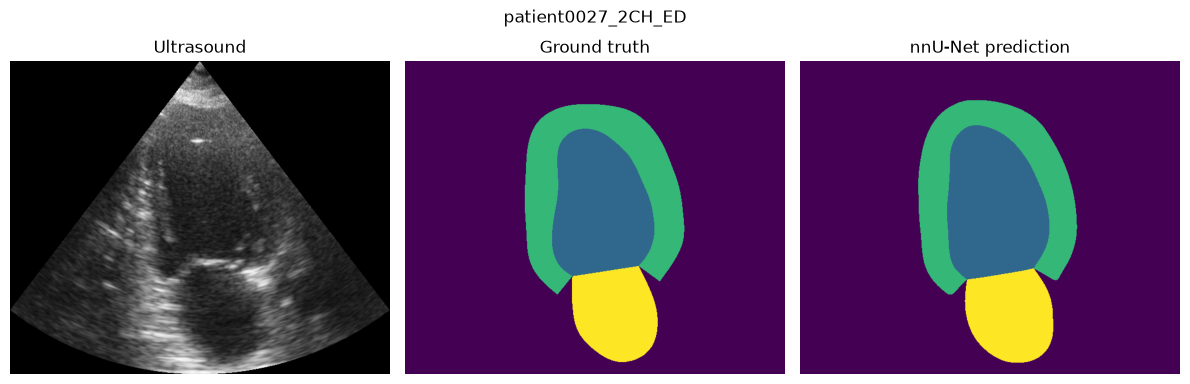

In [4]:
import matplotlib.pyplot as plt

example_case = TEST_CASE_IDS[0]
example_patient = example_case.split("_")[0]
image = np.asarray(
    nib.load(CAMUS_ROOT / example_patient / f"{example_case}.nii.gz").dataobj
).squeeze()
target = np.asarray(nib.load(TEST_LABELS / f"{example_case}.nii.gz").dataobj).squeeze()
prediction = np.asarray(nib.load(PREDICTIONS / f"{example_case}.nii.gz").dataobj).squeeze()

figure, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image.T, cmap="gray")
axes[0].set_title("Ultrasound")
axes[1].imshow(target.T, cmap="viridis", vmin=0, vmax=3)
axes[1].set_title("Ground truth")
axes[2].imshow(prediction.T, cmap="viridis", vmin=0, vmax=3)
axes[2].set_title("nnU-Net prediction")
for axis in axes:
    axis.axis("off")
figure.suptitle(example_case)
plt.tight_layout()


## Final understanding

This experiment did not remove the core deep-learning process. nnU-Net still constructed a U-Net, performed forward propagation, calculated a segmentation loss, backpropagated gradients, and updated convolution weights.

What we specified:

- the CAMUS cases and four labels;
- the patient-level 400/50/50 split;
- one 2D model using fold 0;
- the held-out test metric.

What nnU-Net automated:

- resampling and normalization;
- patch size and batch size;
- U-Net depth and channel widths;
- augmentation, loss details, optimizer schedule, checkpointing, and inference.
